In [3]:
# load packages
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.outliers_influence as oi
import statsmodels.stats.api as sms
import xgboost as xgb                        # Data visualization library, extension of matplotlib  
import random                                           # Randomly generating numbers
import math      

from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix 
from statsmodels.compat import lzip
from statsmodels.graphics.gofplots import qqplot

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import scipy.stats as stats                             # Fit of distribution plot
from sklearn.model_selection import train_test_split    # Split train-/testset     
from sklearn.tree import DecisionTreeClassifier         # Modeling CART Decision Tree  
from sklearn import metrics                             # Performance metrics
from sklearn.metrics import accuracy_score              # Accuracy of a model
from sklearn.metrics import classification_report       # Performance report of a classification model
#import graphviz as gv                                   # Needed to graph Decision Tree
#import pydotplus                                        # Needed to graph Decision Tree
from IPython.display import Image                       # Needed to graph Decision Tree
#from sklearn.externals.six import StringIO              # Needed to graph Decision Tree
from sklearn.tree import export_graphviz                # Needed to graph Decision Tree

#    Define function for the MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true-y_pred)/y_true))*100

print('All packages loaded')


All packages loaded


## Load Data

In [4]:
# Read file
#os.chdir("C:/Users/gijsbartholomeus/Mijn map/FMT_training/Jupyter/FMT/1. Ice cream shop case (small case)")
inputdata = pd.read_csv("ice_cream_shop_dataset.csv", delimiter=',')

inputdata_orig = inputdata.copy() #save an original copy of the file, so that the unaltered data is stored
inputdata.describe()      #look at distribution of variables


,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2.500000,0.287671,0.279452,0.263014,16.927002,1.832877,1008.902122,570.010083
std,0.404304,0.453298,0.449346,0.440874,8.050327,1.530644,15.492243,121.808690
min,2.000000,0.000000,0.000000,0.000000,-6.902214,0.000000,972.586044,11.526294
25%,2.000000,0.000000,0.000000,0.000000,11.710688,1.000000,997.658712,500.536499
50%,2.500000,0.000000,0.000000,0.000000,16.687949,2.000000,1008.493965,582.646044
75%,3.000000,1.000000,1.000000,1.000000,22.374685,3.000000,1019.825477,654.825829
max,3.000000,1.000000,1.000000,1.000000,35.764096,7.000000,1059.213020,823.304392


## Inspection of Data

<Axes: >

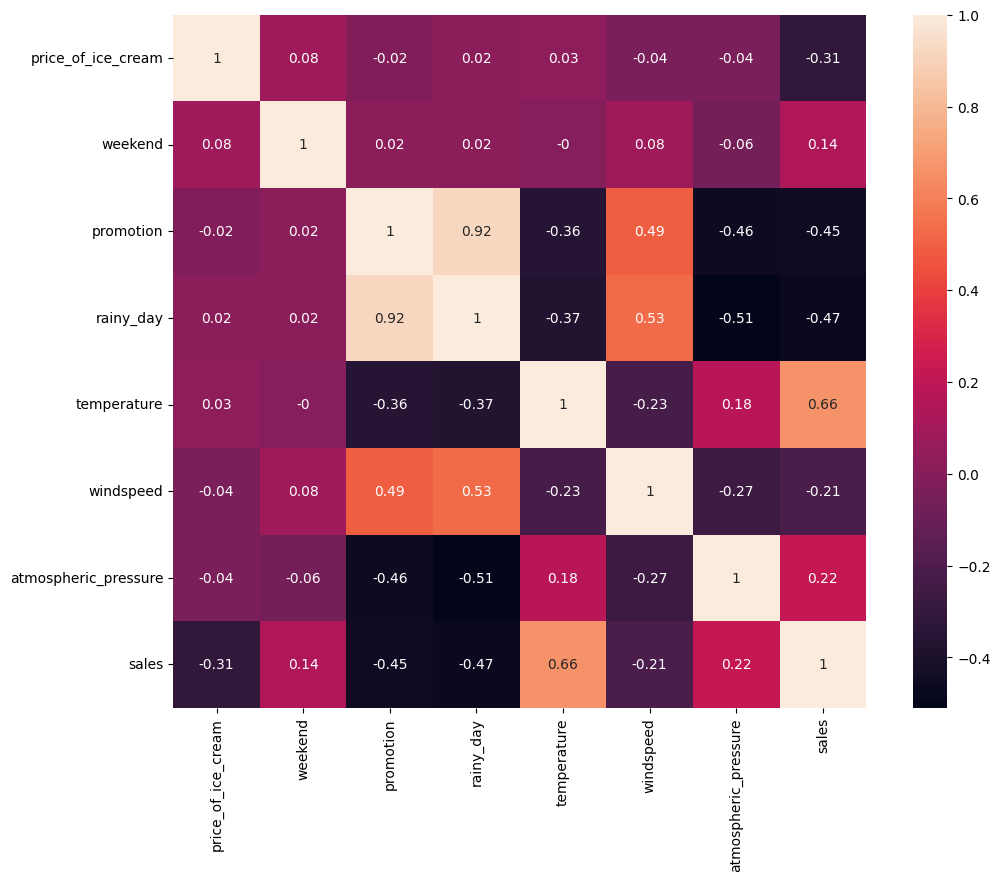

In [5]:
# Inspection of data
corrMat = inputdata.corr().round(2)
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(corrMat, square=True, annot= True)

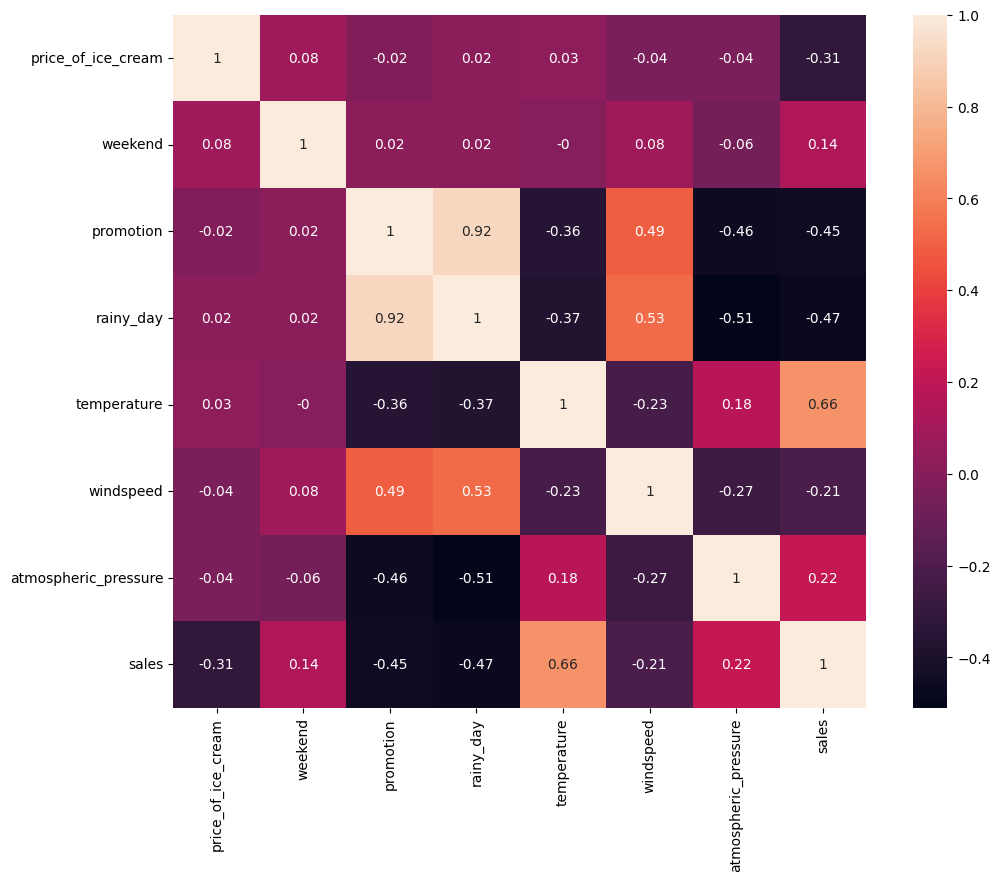

In [6]:
f

## Splitting in train- and testset

In [7]:
trainset, testset = train_test_split(inputdata, test_size=0.3, random_state=13)
print(inputdata.shape)  #print number of rows and columns in inputdata
print(trainset.shape) #print number of rows and columns in trainset   
print(testset.shape)  #print number of rows and columns in testset
print(trainset.columns)

(365, 8)
(255, 8)
(110, 8)
Index(['price_of_ice_cream', 'weekend', 'promotion', 'rainy_day',
       'temperature', 'windspeed', 'atmospheric_pressure', 'sales'],
      dtype='object')


## Applying linear regression - build the model

In [8]:
# a) Build the model using the training sets
y_train = trainset['sales']
X_train = trainset['temperature']
X_train_incl_constant = sm.add_constant(X_train) # in this package, we have to add a constant explicitly

model = sm.OLS(y_train, X_train_incl_constant)
results = model.fit()
print(results.summary())

X_train = trainset[['temperature','price_of_ice_cream']]
X_train_incl_constant = sm.add_constant(X_train) # in this package, we have to add a constant explicitly

model = sm.OLS(y_train, X_train_incl_constant)
results = model.fit()
print(results.summary())

X_train = trainset[['temperature', 'price_of_ice_cream', 'weekend']]
X_train_incl_constant = sm.add_constant(X_train) # in this package, we have to add a constant explicitly

model = sm.OLS(y_train, X_train_incl_constant)
results = model.fit()
print(results.summary())

X_train = trainset[['temperature', 'price_of_ice_cream', 'weekend','rainy_day']]
X_train_incl_constant = sm.add_constant(X_train) # in this package, we have to add a constant explicitly

model = sm.OLS(y_train, X_train_incl_constant)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     234.5
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           6.59e-38
Time:                        10:44:44   Log-Likelihood:                -1516.3
No. Observations:                 255   AIC:                             3037.
Df Residuals:                     253   BIC:                             3044.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         387.5880     13.062     29.672      

# Checking the model

#### checking non-linearity: plot independent variable versus dependent variable

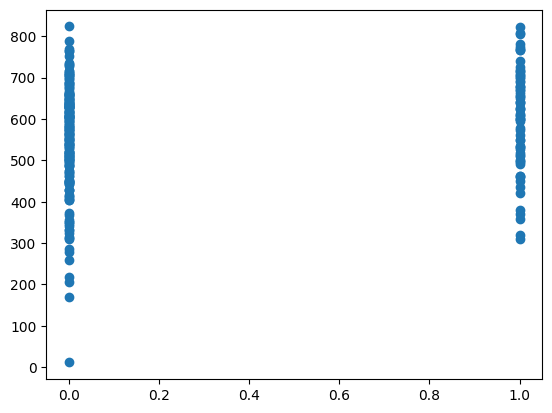

In [9]:
#plt.scatter(trainset['price_of_ice_cream'],trainset['sales'])
#plt.show()
#plt.scatter(trainset['temperature'],trainset['sales'])
#plt.show()
plt.scatter(trainset['weekend'],trainset['sales'])
plt.show()
#plt.scatter(trainset['windspeed'],trainset['sales'])
#plt.show()
#plt.scatter(trainset['promotion'],trainset['sales'])
#plt.show()
#plt.scatter(trainset['rainy_day'],trainset['sales'])
#plt.show()

In [10]:
### Evidence for non-linearity in temperatures found. sales increase until temperature of 25 degrees, but decreases after this temperature is reached
### Conclusion: Add square of temperature to the model: trainset['temperature'].pow(2)
### R^2 improves hugely!

X_train = trainset[['temperature', 'price_of_ice_cream', 'weekend','rainy_day']]
X_train['temp2'] = trainset['temperature'].pow(2)
X_train_incl_constant = sm.add_constant(X_train) # in this package, we have to add a constant explicitly


model = sm.OLS(y_train, X_train_incl_constant)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     191.9
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           2.87e-83
Time:                        10:44:45   Log-Likelihood:                -1398.5
No. Observations:                 255   AIC:                             2809.
Df Residuals:                     249   BIC:                             2830.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                601.2110     25

C:\Users\WoutervanWessel\AppData\Local\Temp\ipykernel_25200\341845269.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['temp2'] = trainset['temperature'].pow(2)


# Checking multicollinearity

In [11]:
X_train = trainset[['temperature', 'price_of_ice_cream', 'weekend','rainy_day']]
X_train['temp2'] = trainset['temperature'].pow(2)
X_train_incl_constant = sm.add_constant(X_train)
# Using Vif scores
vif = [[X_train_incl_constant.columns[i],oi.variance_inflation_factor(X_train_incl_constant.values,i)] for i in range(1,X_train_incl_constant.shape[1])]
vif

C:\Users\WoutervanWessel\AppData\Local\Temp\ipykernel_25200\983535292.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['temp2'] = trainset['temperature'].pow(2)


[['temperature', np.float64(10.311036950956874)],
 ['price_of_ice_cream', np.float64(1.0104387261408023)],
 ['weekend', np.float64(1.0046295211004075)],
 ['rainy_day', np.float64(1.1568432526806391)],
 ['temp2', np.float64(10.110402890753578)]]

In [12]:
# now for the full variables set
X_traintot = trainset.drop('sales',axis=1)
X_traintot_incl_constant = sm.add_constant(X_traintot)
vif = [[X_traintot_incl_constant.columns[i],oi.variance_inflation_factor(X_traintot_incl_constant.values,i)] for i in range(1,X_traintot_incl_constant.shape[1])]
vif

[['price_of_ice_cream', np.float64(1.0299265640465625)],
 ['weekend', np.float64(1.0227944663059179)],
 ['promotion', np.float64(7.616182846625697)],
 ['rainy_day', np.float64(8.307368431655894)],
 ['temperature', np.float64(1.167989126027588)],
 ['windspeed', np.float64(1.4545706907667213)],
 ['atmospheric_pressure', np.float64(1.3654514952740855)]]

Maybe we could say that this results shows that forward selection kind of prevents multicollinearity

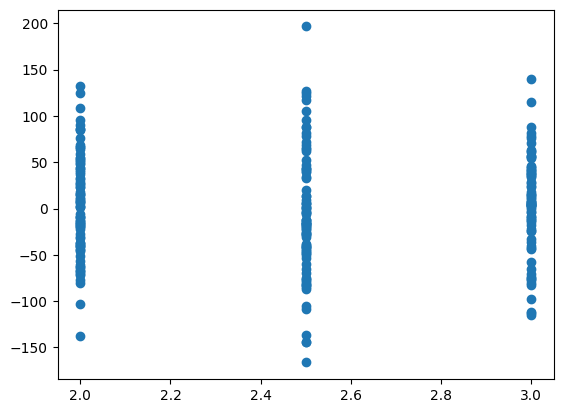

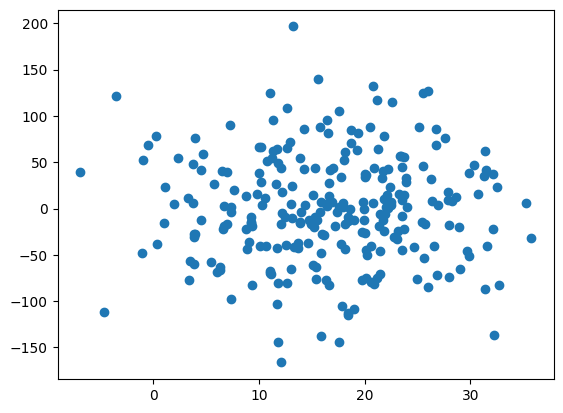

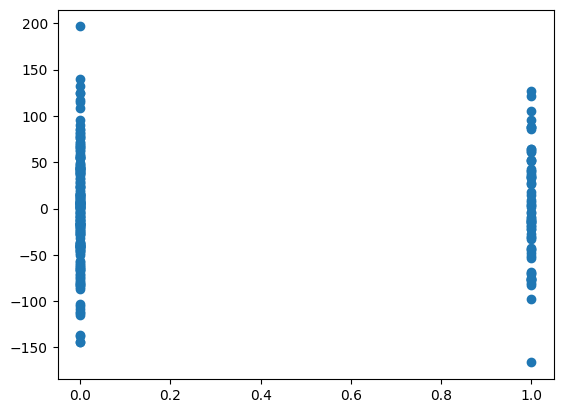

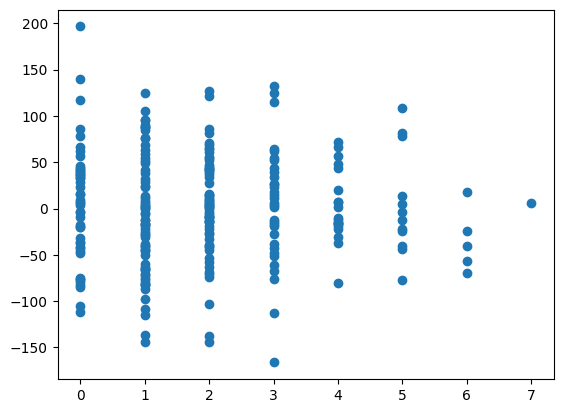

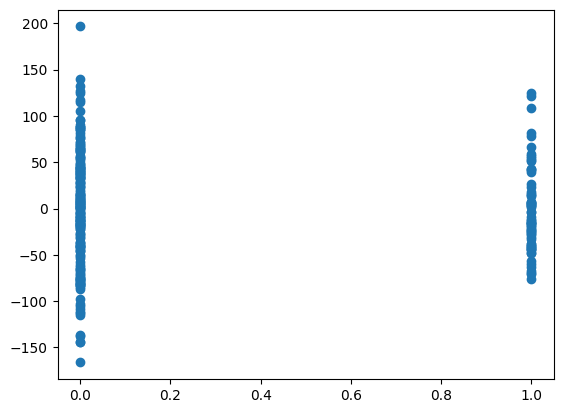

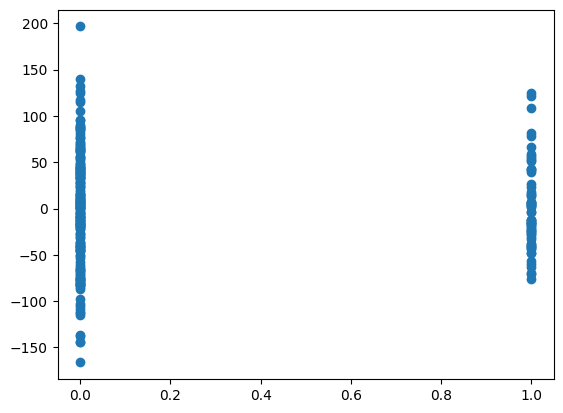

In [13]:
### Checking heteroskedasticity by plotting squared residuals against dependent and independent variables
squaredResids = results.resid
plt.scatter(trainset['price_of_ice_cream'],squaredResids)
plt.show()
plt.scatter(trainset['temperature'],squaredResids)
plt.show()
plt.scatter(trainset['weekend'],squaredResids)
plt.show()
plt.scatter(trainset['windspeed'],squaredResids)
plt.show()
plt.scatter(trainset['promotion'],squaredResids)
plt.show()
plt.scatter(trainset['rainy_day'],squaredResids)
plt.show()

In [14]:
### based on rainy_day and temperature plots, heteroskedasticity might be present
### Breusch-pagan test might be done, so that heteroskedasticity may be formally tested. 
### If p-value <0.05, homoskedasticity is rejected and heteroskedasticity is assumed
### First output is the LM statistic, the second its p-value, you want to use this one
### Third output is the F statistic, the fourth its p-value
het_breuschpagan(results.resid, X_train_incl_constant)

(np.float64(8.832717739883133),
 np.float64(0.11592541136890346),
 np.float64(1.7868716728219975),
 np.float64(0.11602294233315551))

In [15]:
### So now we use a robust regression with white standard errors. In code: cov_type='HC0'
model = sm.OLS(y_train, X_train_incl_constant)
results = model.fit(cov_type='HC0')
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     226.7
Date:                Thu, 20 Nov 2025   Prob (F-statistic):           1.64e-90
Time:                        10:44:46   Log-Likelihood:                -1398.5
No. Observations:                 255   AIC:                             2809.
Df Residuals:                     249   BIC:                             2830.
Df Model:                           5                                         
Covariance Type:                  HC0                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                601.2110     22

Finally, we compute predictions

In [16]:
X_test = testset[['temperature', 'price_of_ice_cream', 'weekend','rainy_day']]
X_test['temp2']=X_test['temperature'].pow(2)
predict_linear = results.predict(sm.add_constant(X_test))

C:\Users\WoutervanWessel\AppData\Local\Temp\ipykernel_25200\169617506.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['temp2']=X_test['temperature'].pow(2)


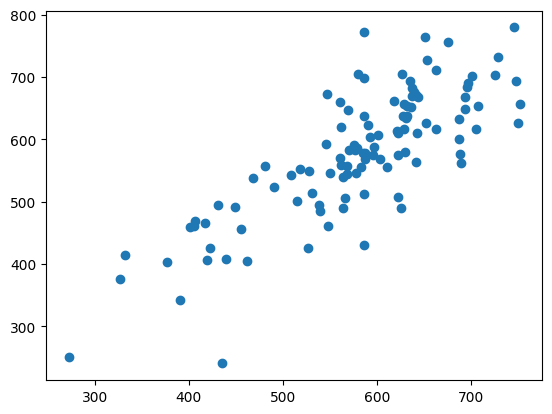

MSE:
3984.935624008385
MAE:
48.478873362947894
MAPE:
9.032022720969445


In [17]:
# And test using plots and 3 measures
plt.scatter(predict_linear,testset['sales'])
plt.show()
print("MSE:")
print(mean_squared_error(testset['sales'],predict_linear))
print("MAE:")
print(mean_absolute_error(testset['sales'],predict_linear))
print("MAPE:")
print(mean_absolute_percentage_error(testset['sales'],predict_linear))

# logit regression

In [18]:
X_train = trainset[['atmospheric_pressure','temperature','windspeed']]
X_train_constant = sm.add_constant(X_train)
logit_model = sm.GLM(trainset['rainy_day'], X_train_constant, family=sm.families.Binomial())
result = logit_model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              rainy_day   No. Observations:                  255
Model:                            GLM   Df Residuals:                      251
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67.521
Date:                Thu, 20 Nov 2025   Deviance:                       135.04
Time:                        10:44:47   Pearson chi2:                     182.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4589
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  108.9784 

In [19]:
## Standardize independent variables so that relative importance can be assessed
atmospheric_pressure_standardized = (trainset['atmospheric_pressure'] - np.mean(trainset['atmospheric_pressure']))/np.std(trainset['atmospheric_pressure'])
temperature_standardized = (trainset['temperature'] - np.mean(trainset['temperature']))/np.std(trainset['temperature'])
windspeed_standardized = (trainset['windspeed'] - np.mean(trainset['windspeed']))/np.std(trainset['windspeed'])
rainy_day = trainset['rainy_day']
standardized_trainset = pd.DataFrame({
    'atmospheric_pressure_standardized': atmospheric_pressure_standardized,
    'temperature_standardized': temperature_standardized,
    'windspeed_standardized':windspeed_standardized,
    'rainy_day':rainy_day})
standardized_trainset.head()

,atmospheric_pressure_standardized,temperature_standardized,windspeed_standardized,rainy_day
192,0.807983,-1.243436,-0.574917,0
196,0.408595,0.777199,0.085461,1
203,0.246029,1.241881,-1.235295,0
311,0.259562,-0.058260,-0.574917,0
41,2.229671,-1.775994,0.085461,0


In [20]:
# Now create the model for the standardized dataset
standardized_trainset_constant = sm.add_constant(standardized_trainset)
logit_model_stand = sm.GLM(standardized_trainset_constant['rainy_day'], standardized_trainset_constant.drop('rainy_day',axis=1), family=sm.families.Binomial())
result_stand = logit_model_stand.fit()
print(result_stand.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              rainy_day   No. Observations:                  255
Model:                            GLM   Df Residuals:                      251
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67.521
Date:                Thu, 20 Nov 2025   Deviance:                       135.04
Time:                        10:44:47   Pearson chi2:                     182.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4589
Covariance Type:            nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [21]:
#Compute predictions for the test set, using the non-scaled model
X_test = testset[['atmospheric_pressure','temperature','windspeed']]
proba_logit = result.predict(sm.add_constant(X_test))
# Now using the cut off, create predictions for the test set
cut_off = 0.4

# Initialize prediction vector as zeros and fill in ones where probability > cut-off
predict_logit = np.zeros(X_test.shape[0])
predict_logit[proba_logit > cut_off] = 1

# Print confusion matrix
tn,fp,fn,tp = confusion_matrix(testset['rainy_day'],predict_logit).ravel()
print("True negative:")
print(tn)
print("False postive:")
print(fp)
print("False negative:")
print(fn)
print("True postive:")
print(tp)

True negative:
72
False postive:
8
False negative:
8
True postive:
22


# 5. CART Decision tree

<a id="5a"></a> 
### A) Decision Tree CART

In [22]:
# Define X and y 
X_variables = ['atmospheric_pressure','temperature','windspeed'
              ]
y_variable = 'rainy_day'

X_train = trainset.loc[:, X_variables]
y_train = trainset[y_variable]
X_test = testset.loc[:, X_variables]
y_test = testset[y_variable]

In [23]:
# a) Set model parameters 
#    Note: if Min_bucket is too large, the tree might not branch, if too small, the tree might get to big to interpret
Min_num_splits = 50                            # Minimum number of items to split
Min_bucket     = math.floor(Min_num_splits/3)  # Minimum number of items per bucket
Max_depth      = 5                             # Maximum depth of final tree (nr of levels)

In [24]:
# b) Estimate the model 
mytree = DecisionTreeClassifier(max_depth=Max_depth
                                ,min_samples_split=Min_num_splits
                                ,min_samples_leaf=Min_bucket
                                ,criterion="gini"              
                                ,splitter="best"
                                ,random_state=random.seed()
                                )

mytree.fit(X_train, y_train)     # Fit the model over the train set

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,50
,min_samples_leaf,16
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
# c) Create predictions for the test set
preds_proba = mytree.predict_proba(X_test)
preds = mytree.predict(X_test)   # Cut-off point equals 0.5

#    Show the first 5 lines of the prediction probabilities and corresponding prediction
pd.concat([pd.DataFrame(preds_proba, columns=["Prob. 0", "Prob. 1"]), pd.DataFrame(preds, columns=["Prediction"])], axis=1).head()

,Prob. 0,Prob. 1,Prediction
0,0.071429,0.928571,1
1,0.071429,0.928571,1
2,0.071429,0.928571,1
3,0.840909,0.159091,0
4,1.000000,0.000000,0


In [26]:
#    Calculate the optimal cut-off point
cost_TP = 50
cost_TN = 0
cost_FP = 50
cost_FN = 100
total_cost = math.inf

for i in np.linspace(0,1,100,endpoint=False):
    y_pred = (preds_proba[:,1]>i).astype('int')
    results = metrics.confusion_matrix(y_pred,y_test)
    TN = results[0][0]
    FN = results[0][1]
    FP = results[1][0]
    TP = results[1][1]
    
    # Calculate cutoff-point
    cost = TN*cost_TN + TP*cost_TP + FP*cost_FP + FN*cost_FN
    total_cost = min(total_cost,cost)
    if(total_cost == cost):
        opt_cutoff = i
        
print('Optimal cut-off:', opt_cutoff)

#    Create predictions for the test set according to optimal cutoff point
preds = (preds_proba[:,1] > opt_cutoff).astype('int')

Optimal cut-off: 0.92


In [27]:
# d) Evaluate results
#    i. Create confusion matrix
print(pd.crosstab(preds, y_test))

rainy_day   0   1
row_0            
0          78  18
1           2  12


In [28]:
#    ii. Create classification report
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.81      0.97      0.89        80
           1       0.86      0.40      0.55        30

    accuracy                           0.82       110
   macro avg       0.83      0.69      0.72       110
weighted avg       0.82      0.82      0.79       110



Feature ranking:
Feature 0 (atmospheric_pressure) 0.575981
Feature 2 (windspeed) 0.424019
Feature 1 (temperature) 0.000000


<Figure size 750x500 with 0 Axes>

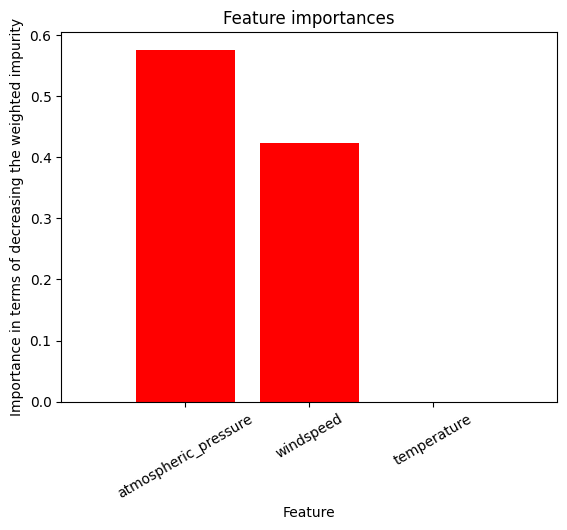

In [29]:
#    iii. Get the feature importances of the tree
importances = mytree.feature_importances_ 
std = np.std([mytree.feature_importances_], axis=0)
indices = np.argsort(importances)[::-1]

importances_features = []
print("Feature ranking:")                    # Print the feature ranking
for f in range(X_train.shape[1]):
    print("Feature %d (%s) %f" % (indices[f], X_variables[indices[f]], importances[indices[f]]))
    importances_features.append(X_variables[indices[f]])

plt.figure(figsize=(7.5,5))
plt.figure()                                 # Plot the feature importances 
plt.bar(range(X_train.shape[1]), importances[indices],
       color="r", yerr=std[indices], align="center")
plt.title("Feature importances")
plt.ylabel("Importance in terms of decreasing the weighted impurity")
plt.xlabel("Feature")
plt.xticks(range(X_train.shape[1]), importances_features, rotation = 30)
plt.xlim([-1, X_train.shape[1]])
plt.show()

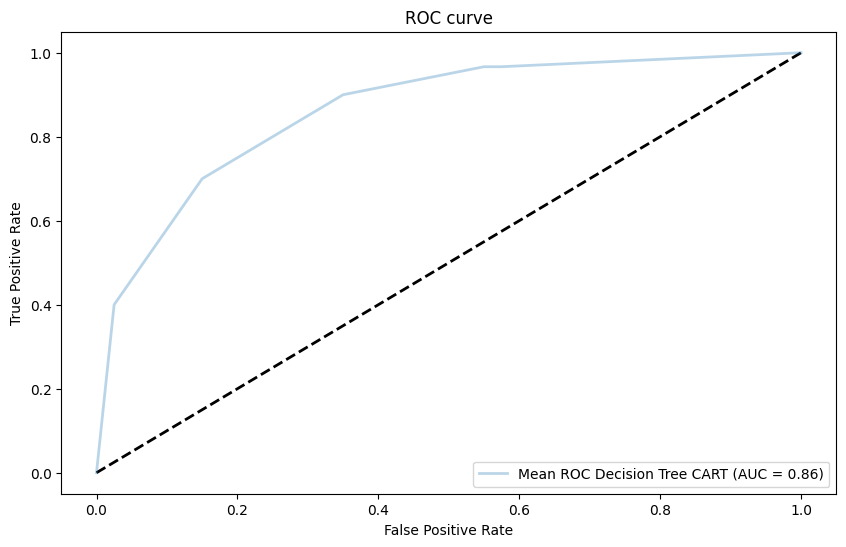

In [30]:
#    iv. Create ROC curve
fpr, tpr, t = metrics.roc_curve(y_test, preds_proba[:,1])

#     v. Calculate AUC
roc_auc_tree = metrics.auc(fpr, tpr)

plt.figure(figsize=(10,6))
plt.plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')      # Plot results
plt.plot(fpr, tpr, lw=2, alpha=0.3, label='Mean ROC Decision Tree CART (AUC = %0.2f)' % (roc_auc_tree))
plt.title('ROC curve')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc="lower right")
plt.show()

    fpr  tpr  1-fpr    tf  thresholds
2  0.15  0.7   0.85 -0.15    0.571429


[Text(-1.0, 0, ''),
 Text(0.0, 0, ''),
 Text(1.0, 0, ''),
 Text(2.0, 0, ''),
 Text(3.0, 0, ''),
 Text(4.0, 0, ''),
 Text(5.0, 0, ''),
 Text(6.0, 0, ''),
 Text(7.0, 0, '')]

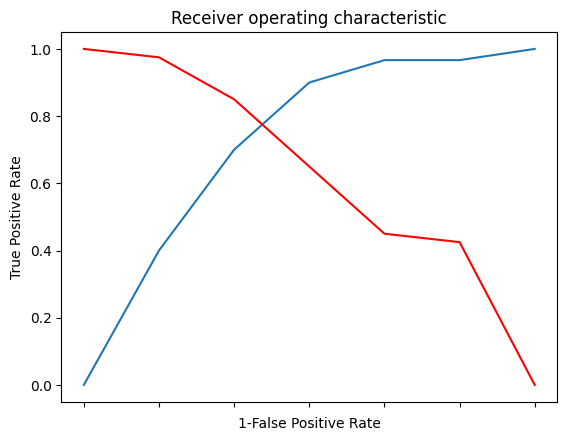

In [31]:
#    Plot tpr vs 1-fpr
i = np.arange(len(tpr)) # index for df
roc = pd.DataFrame({'fpr' : pd.Series(fpr, index=i),'tpr' : pd.Series(tpr, index = i)
                    ,'1-fpr' : pd.Series(1-fpr, index = i)
                    ,'tf' : pd.Series(tpr - (1-fpr), index = i)
                    ,'thresholds' : pd.Series(t, index = i)})
print(roc.loc[(roc.tf-0).abs().argsort()[:1]])
fig, ax = plt.subplots()
plt.plot(roc['tpr'])
plt.plot(roc['1-fpr'], color = 'red')
plt.title('Receiver operating characteristic')
plt.ylabel('True Positive Rate')
plt.xlabel('1-False Positive Rate')
ax.set_xticklabels([])

# K-means
In this section we will run a k-means clustering algorithm on the dataset and inspect whether we find any meaningful clustering

In [32]:
trainset, testset = train_test_split(inputdata, test_size=0.3, random_state=13)
print(inputdata.shape)  #print number of rows and columns in inputdata
print(trainset.shape) #print number of rows and columns in trainset   
print(testset.shape)  #print number of rows and columns in testset
print(trainset.columns)

(365, 8)
(255, 8)
(110, 8)
Index(['price_of_ice_cream', 'weekend', 'promotion', 'rainy_day',
       'temperature', 'windspeed', 'atmospheric_pressure', 'sales'],
      dtype='object')


In [33]:
# Fit the kmeans with two clusters
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(trainset)

In [34]:
# Show the predictions
trainset['group'] = kmeans.labels_
trainset

,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales,group
192,2.0,0,0,0,6.353489,1,1021.958006,449.317955,1
196,3.0,1,1,1,23.069946,2,1015.691881,534.542595,1
203,3.0,1,0,0,26.914200,0,1013.141325,639.786612,0
311,2.5,0,0,0,16.158293,1,1013.353655,570.780508,0
41,3.0,0,0,0,1.947700,2,1044.263357,308.899495,1
...,...,...,...,...,...,...,...,...,...
230,2.0,0,0,0,30.699517,0,1000.061526,704.447883,0
16,3.0,0,0,0,23.327213,0,1005.231852,641.072309,0
74,2.0,0,0,0,19.722919,5,1025.703719,607.600516,0
176,2.5,1,0,0,11.751798,3,1045.190013,661.467295,0


In [35]:
# Summarize statistics for group 0
trainset[trainset['group']==0].describe()

,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales,group
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.0
mean,2.422581,0.296774,0.116129,0.103226,20.386700,1.574194,1012.077544,648.784805,0.0
std,0.399439,0.458317,0.321418,0.305240,6.032629,1.409377,15.534783,64.618848,0.0
min,2.000000,0.000000,0.000000,0.000000,6.468503,0.000000,972.586044,546.022828,0.0
25%,2.000000,0.000000,0.000000,0.000000,15.830237,0.000000,1000.143737,602.692802,0.0
50%,2.500000,0.000000,0.000000,0.000000,20.254617,1.000000,1012.452217,639.484584,0.0
75%,2.750000,1.000000,0.000000,0.000000,23.962960,2.000000,1021.784692,690.182825,0.0
max,3.000000,1.000000,1.000000,1.000000,35.764096,7.000000,1059.213020,823.304392,0.0


In [36]:
# Summarize statistics for group 1
trainset[trainset['group']==1].describe()

,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales,group
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0
mean,2.595000,0.220000,0.510000,0.500000,10.833315,2.330000,1004.947109,439.509785,1.0
std,0.387266,0.416333,0.502418,0.502519,7.977386,1.570273,15.080391,95.283034,0.0
min,2.000000,0.000000,0.000000,0.000000,-6.902214,0.000000,973.086550,11.526294,1.0
25%,2.500000,0.000000,0.000000,0.000000,5.261786,1.000000,993.717162,397.412902,1.0
50%,2.500000,0.000000,1.000000,0.500000,10.042732,2.000000,1004.244244,462.677154,1.0
75%,3.000000,0.000000,1.000000,1.000000,15.780045,3.000000,1015.719932,509.583196,1.0
max,3.000000,1.000000,1.000000,1.000000,32.715204,6.000000,1044.263357,541.706994,1.0


In [37]:
# Plot the cluster centers
pd.DataFrame(kmeans.cluster_centers_,columns=inputdata.columns)

,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales
0,2.422581,0.296774,0.116129,0.103226,20.386700,1.574194,1012.077544,648.784805
1,2.595000,0.220000,0.510000,0.500000,10.833315,2.330000,1004.947109,439.509785


In [38]:
# Predict on the testset
testset['group'] = kmeans.predict(testset)
testset

,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales,group
214,2.5,0,1,1,8.537325,5,987.017981,493.751656,1
251,2.0,0,0,0,20.269553,4,1001.273478,576.584128,0
27,3.0,0,1,1,22.262608,4,994.835859,500.536499,1
61,2.5,0,1,1,8.025424,1,982.822139,426.245148,1
337,2.0,1,1,0,18.887452,1,1035.605724,732.011013,0
...,...,...,...,...,...,...,...,...,...
127,2.0,1,0,0,25.514749,1,1033.919947,656.849027,0
286,2.0,0,0,0,30.515422,1,1021.317235,561.408426,0
237,2.0,0,0,0,13.549766,1,996.071985,656.137887,0
348,2.0,0,0,0,30.859395,0,1019.825477,633.261191,0


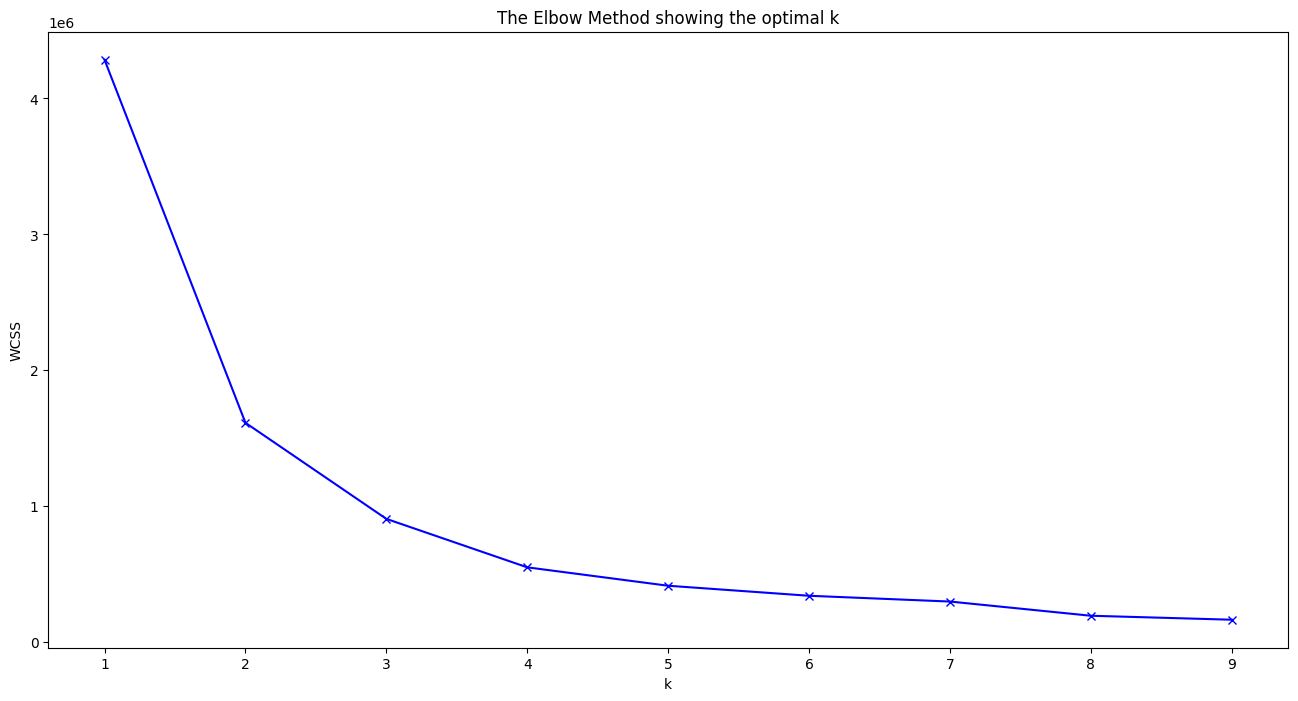

In [40]:
# Create an elbow plot
WCSS = []
K = range(1,10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=0, n_init="auto")
    kmeanModel.fit(trainset)
    WCSS.append(kmeanModel.inertia_)
    
plt.figure(figsize=(16,8))
plt.plot(K, WCSS, 'bx-')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.title('The Elbow Method showing the optimal k')
plt.show()

In [41]:
# Does this differ when we standardize
scale = StandardScaler()
scaled_data = pd.DataFrame(scale.fit_transform(inputdata), columns=inputdata.columns)
trainset, testset = train_test_split(scaled_data, test_size=0.3, random_state=13)

In [42]:
# Fit the kmeans with two clusters
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(trainset)
trainset = pd.DataFrame(scale.inverse_transform(trainset), columns=inputdata.columns)
trainset['group'] = kmeans.labels_
trainset

,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales,group
0,2.0,0.0,0.0,0.0,6.353489,1.000000e+00,1021.958006,449.317955,1
1,3.0,1.0,1.0,1.0,23.069946,2.000000e+00,1015.691881,534.542595,0
2,3.0,1.0,0.0,0.0,26.914200,-2.220446e-16,1013.141325,639.786612,1
3,2.5,0.0,0.0,0.0,16.158293,1.000000e+00,1013.353655,570.780508,1
4,3.0,0.0,0.0,0.0,1.947700,2.000000e+00,1044.263357,308.899495,1
...,...,...,...,...,...,...,...,...,...
250,2.0,0.0,0.0,0.0,30.699517,-2.220446e-16,1000.061526,704.447883,1
251,3.0,0.0,0.0,0.0,23.327213,-2.220446e-16,1005.231852,641.072309,1
252,2.0,0.0,0.0,0.0,19.722919,5.000000e+00,1025.703719,607.600516,1
253,2.5,1.0,0.0,0.0,11.751798,3.000000e+00,1045.190013,661.467295,1


In [43]:
# Summarize statistics for group 0
trainset[trainset['group']==0].describe()

,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales,group
count,66.000000,66.000000,66.000000,66.0,66.000000,6.600000e+01,66.000000,66.000000,66.0
mean,2.507576,0.287879,0.969697,1.0,11.546097,3.272727e+00,995.620961,466.453871,0.0
std,0.377160,0.456244,0.172733,0.0,7.140124,1.612885e+00,9.968789,110.391506,0.0
min,2.000000,0.000000,0.000000,1.0,-3.534905,-2.220446e-16,973.086550,169.664057,0.0
25%,2.000000,0.000000,1.000000,1.0,6.604771,2.000000e+00,989.097261,386.307041,0.0
50%,2.500000,0.000000,1.000000,1.0,11.049827,3.000000e+00,995.299377,487.247947,0.0
75%,3.000000,1.000000,1.000000,1.0,17.566209,4.750000e+00,1003.204400,534.855843,0.0
max,3.000000,1.000000,1.000000,1.0,23.412262,7.000000e+00,1015.691881,660.780437,0.0


In [44]:
# Summarize statistics for group 1
trainset[trainset['group']==1].describe()

,price_of_ice_cream,weekend,promotion,rainy_day,temperature,windspeed,atmospheric_pressure,sales,group
count,189.000000,189.000000,189.000000,189.0,189.000000,1.890000e+02,189.000000,189.000000,189.0
mean,2.484127,0.259259,0.026455,0.0,18.419194,1.380952e+00,1014.051570,601.728401,1.0
std,0.412261,0.439392,0.160910,0.0,7.931781,1.131210e+00,14.530490,115.700875,0.0
min,2.000000,0.000000,0.000000,0.0,-6.902214,-2.220446e-16,972.586044,11.526294,1.0
25%,2.000000,0.000000,0.000000,0.0,13.005699,1.000000e+00,1003.498883,538.802398,1.0
50%,2.500000,0.000000,0.000000,0.0,18.462915,1.000000e+00,1014.675177,618.504545,1.0
75%,3.000000,1.000000,0.000000,0.0,23.711660,2.000000e+00,1023.309021,678.068131,1.0
max,3.000000,1.000000,1.000000,0.0,35.764096,5.000000e+00,1059.213020,823.304392,1.0
